# Anhedonic AI — Visualizing Steering Vectors

This notebook visualizes the activations we extracted from Qwen2VL.

**Goal**: Understand where and how strongly the model separates *rewarding* situations from *neutral* ones — so we know where to intervene.

---
## Block 1: Imports

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print('All imports OK')

All imports OK


---
## Block 2: Load the Saved Activations

We load the two `.pt` files produced by `extract_activations.py`.

- `high_reward_activations`: what the model "saw" when reading rewarding sentences
- `neutral_activations`: what the model "saw" when reading neutral sentences

In [8]:
high_reward_activations = torch.load('high_reward_activations.pt')
neutral_activations = torch.load('neutral_activations.pt')
steering_vectors = torch.load('steering_vectors.pt')

num_layers = len(high_reward_activations[0])
num_pairs = len(high_reward_activations)

print(f'Number of layers: {num_layers}')
print(f'Number of sentence pairs: {num_pairs}')

Number of layers: 28
Number of sentence pairs: 200


---
## Block 3: Separation Score Per Layer

For each layer, we measure how different the model's internal state is between reward vs neutral sentences.

**Higher score = the model is more strongly distinguishing the two conditions at that layer.**

This tells us where the "motivation signal" lives.

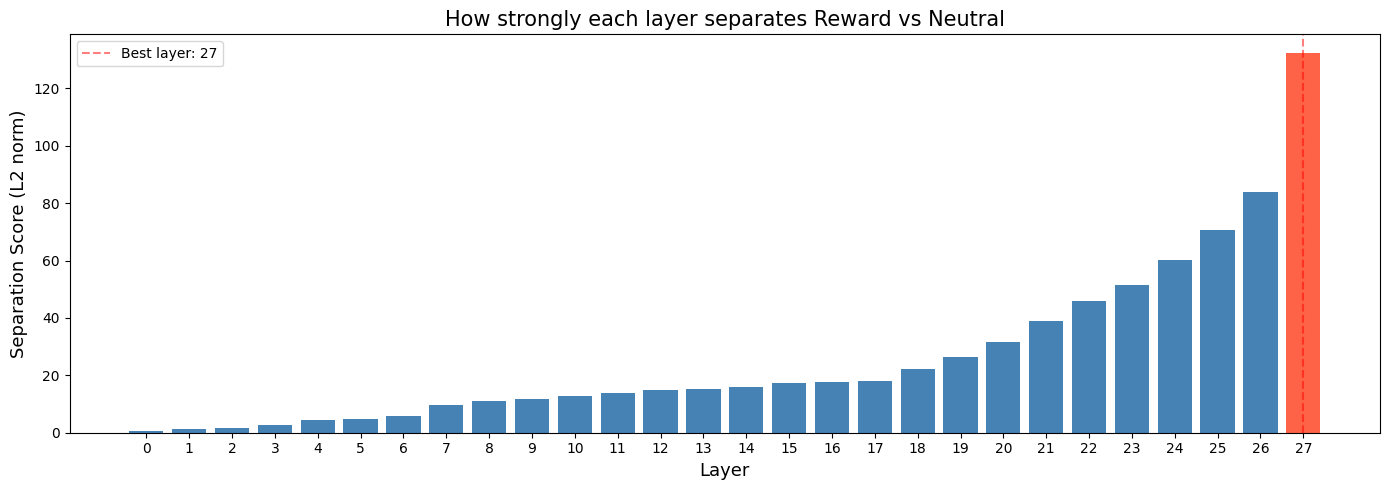

Best layer: 27 with score 132.2500


In [9]:
separation_scores = []

for layer_idx in range(num_layers):
    high_stack = torch.stack([a[layer_idx].squeeze() for a in high_reward_activations])
    neutral_stack = torch.stack([a[layer_idx].squeeze() for a in neutral_activations])
    score = (high_stack.mean(0) - neutral_stack.mean(0)).norm().item()
    separation_scores.append(score)

plt.figure(figsize=(14, 5))
colors = ['tomato' if s == max(separation_scores) else 'steelblue' for s in separation_scores]
plt.bar(range(num_layers), separation_scores, color=colors)
plt.xlabel('Layer', fontsize=13)
plt.ylabel('Separation Score (L2 norm)', fontsize=13)
plt.title('How strongly each layer separates Reward vs Neutral', fontsize=15)
plt.xticks(range(num_layers))
plt.axvline(x=np.argmax(separation_scores), color='red', linestyle='--', alpha=0.5, label=f'Best layer: {np.argmax(separation_scores)}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best layer: {np.argmax(separation_scores)} with score {max(separation_scores):.4f}')

---
## Block 4: PCA — Do the Two Conditions Form Separate Clusters?

We take the activations from the best layer and reduce them to 2D using PCA.

**What we want to see**: Two clearly separated clusters — red (reward) and blue (neutral).

If the clusters are well separated, our steering vector is meaningful.

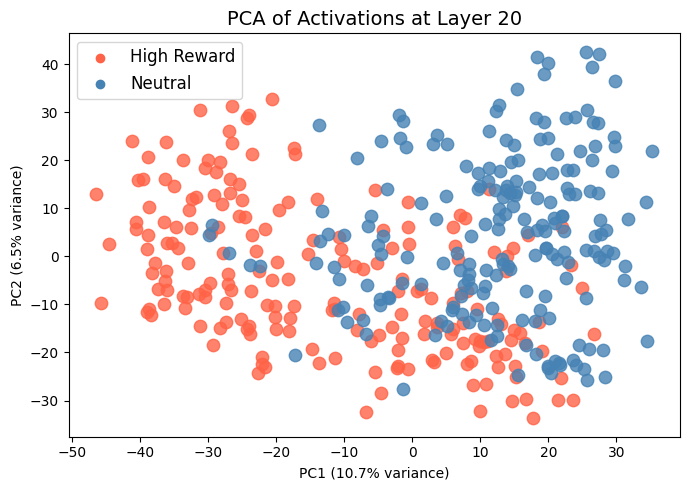

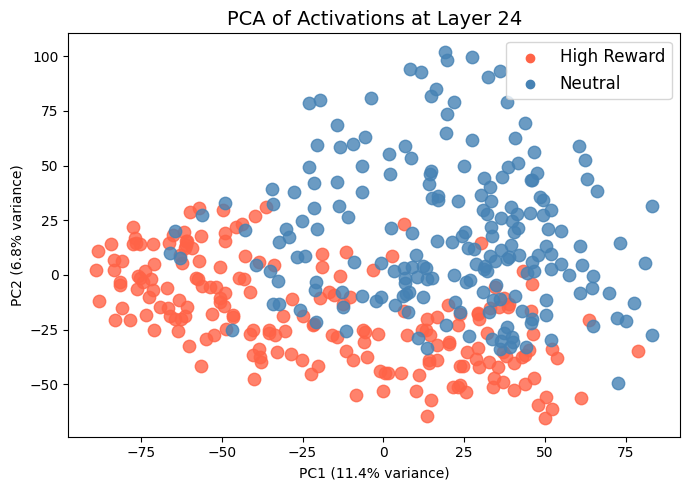

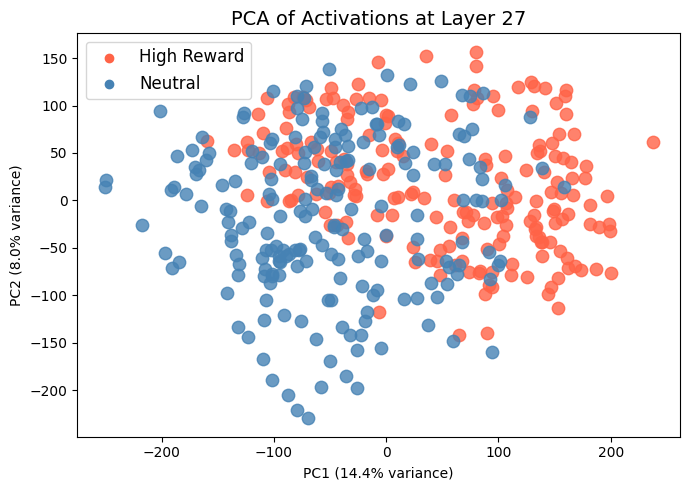

In [10]:
best_layer = int(np.argmax(separation_scores))

# Also try layers 24 and 20 for comparison
for target_layer in [20, 24, best_layer]:
    high_stack = torch.stack([a[target_layer].squeeze() for a in high_reward_activations]).float().numpy()
    neutral_stack = torch.stack([a[target_layer].squeeze() for a in neutral_activations]).float().numpy()

    all_acts = np.concatenate([high_stack, neutral_stack], axis=0)
    labels = ['Reward'] * num_pairs + ['Neutral'] * num_pairs

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(all_acts)

    plt.figure(figsize=(7, 5))
    for i, (x, y) in enumerate(reduced):
        color = 'tomato' if labels[i] == 'Reward' else 'steelblue'
        plt.scatter(x, y, color=color, s=80, alpha=0.8)

    plt.scatter([], [], color='tomato', label='High Reward')
    plt.scatter([], [], color='steelblue', label='Neutral')
    plt.legend(fontsize=12)
    plt.title(f'PCA of Activations at Layer {target_layer}', fontsize=14)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.tight_layout()
    plt.show()

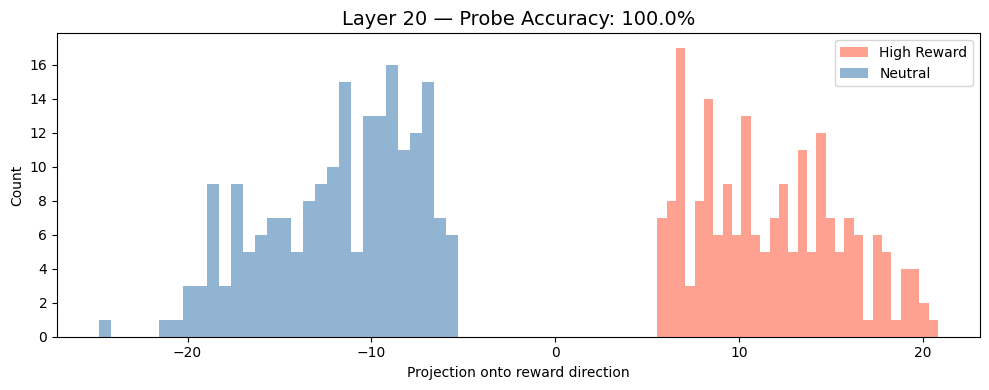

Layer 20: accuracy = 100.0%


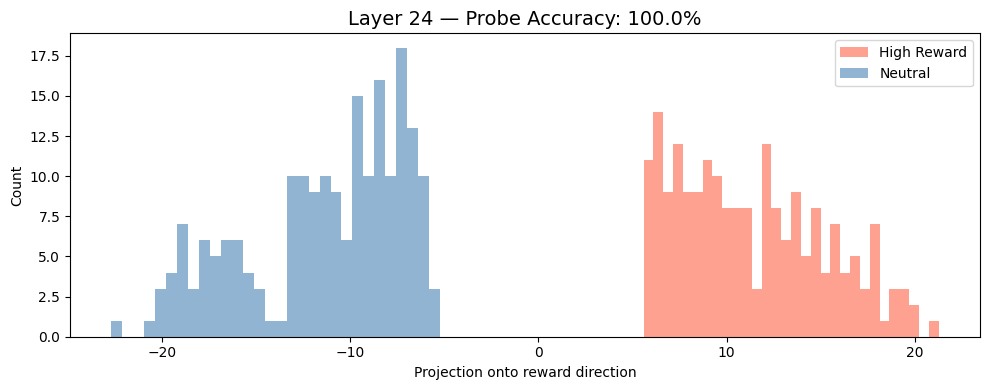

Layer 24: accuracy = 100.0%


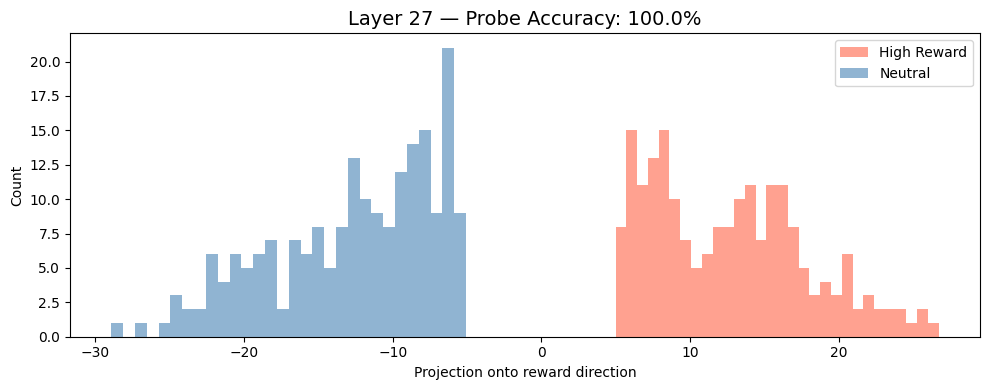

Layer 27: accuracy = 100.0%


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

for target_layer in [20, 24, 27]:
    high_stack = torch.stack([a[target_layer].squeeze() for a in high_reward_activations]).float().numpy()
    neutral_stack = torch.stack([a[target_layer].squeeze() for a in neutral_activations]).float().numpy()

    X = np.concatenate([high_stack, neutral_stack], axis=0)
    y = np.array([1] * len(high_stack) + [0] * len(neutral_stack))

    # Normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train probe
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_scaled, y)
    acc = accuracy_score(y, clf.predict(X_scaled))

    # Project onto the probe direction (1D)
    direction = clf.coef_[0]
    projections = X_scaled @ direction

    plt.figure(figsize=(10, 4))
    plt.hist(projections[y == 1], bins=30, alpha=0.6, color='tomato', label='High Reward')
    plt.hist(projections[y == 0], bins=30, alpha=0.6, color='steelblue', label='Neutral')
    plt.title(f'Layer {target_layer} — Probe Accuracy: {acc*100:.1f}%', fontsize=14)
    plt.xlabel('Projection onto reward direction')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'Layer {target_layer}: accuracy = {acc*100:.1f}%')

---
## Block 5: Steering Vector Magnitude Per Layer

Here we look at the steering vectors we computed — these are the "motivation directions" at each layer.

The magnitude tells us how strongly each layer encodes the difference between reward and neutral.

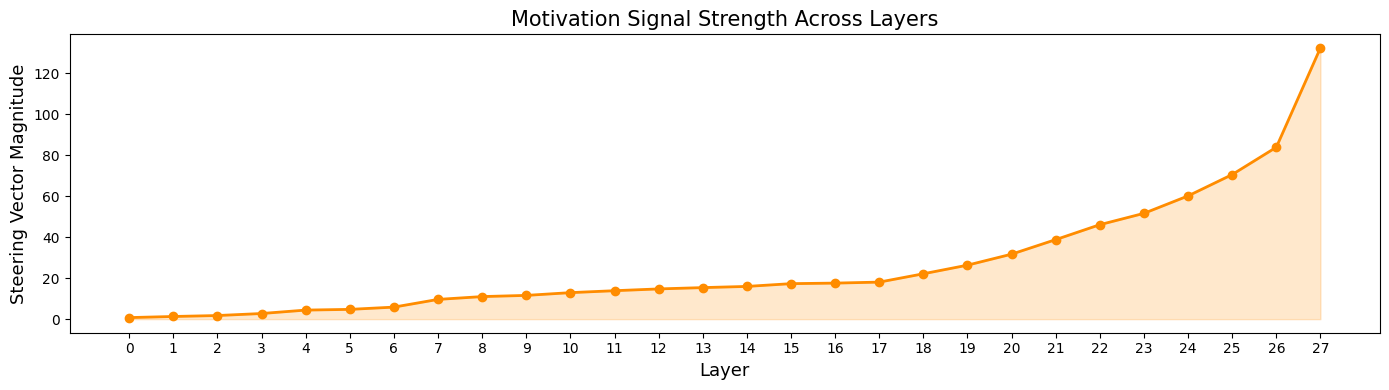

In [12]:
magnitudes = [steering_vectors[i].norm().item() for i in range(num_layers)]

plt.figure(figsize=(14, 4))
plt.plot(range(num_layers), magnitudes, marker='o', color='darkorange', linewidth=2)
plt.fill_between(range(num_layers), magnitudes, alpha=0.2, color='darkorange')
plt.xlabel('Layer', fontsize=13)
plt.ylabel('Steering Vector Magnitude', fontsize=13)
plt.title('Motivation Signal Strength Across Layers', fontsize=15)
plt.xticks(range(num_layers))
plt.tight_layout()
plt.show()

---
## Block 6: Per-Pair Distance at Best Layer

For each of our 30 sentence pairs, we measure how far apart the reward and neutral activations are at the best layer.

**What we want**: Most pairs should show a large distance — meaning the model consistently distinguishes reward from neutral across many different scenarios.

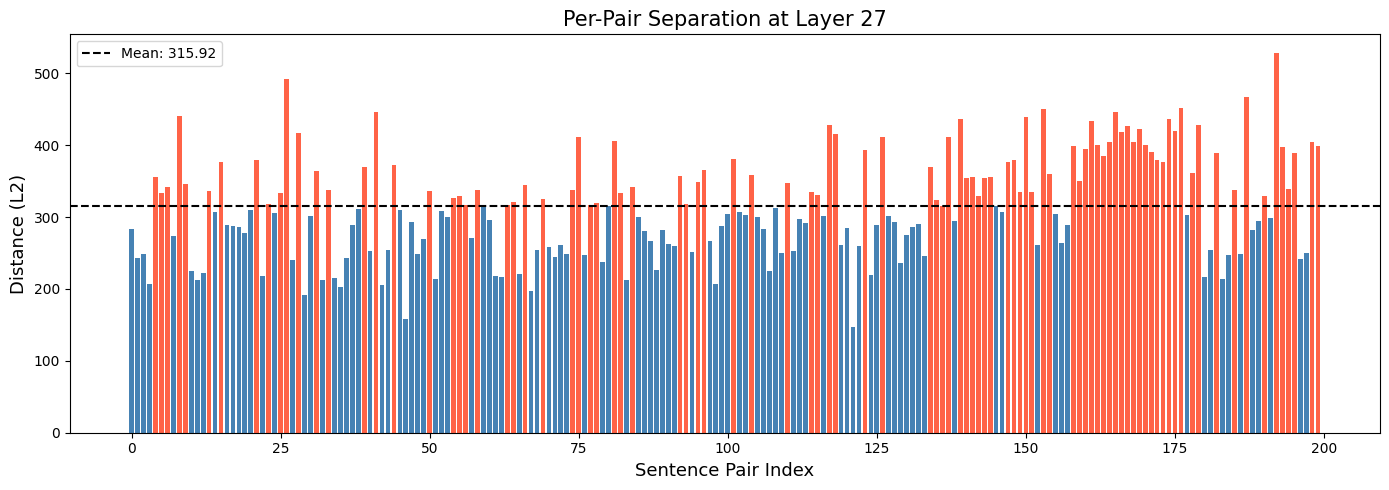

Top 5 most separated pairs:
  Pair 192: 527.79
    Reward:  You bit into a perfectly ripe mango on a hot day and it was absolute perfection.
    Neutral: You ate the apple you packed in your bag this morning.

  Pair 26: 492.44
    Reward:  Everyone at the party is celebrating because of you.
    Neutral: Everyone at the meeting acknowledged your presence.

  Pair 187: 467.39
    Reward:  You held your newborn child for the first time and the world stopped.
    Neutral: You held the door open for someone leaving the building.

  Pair 176: 452.19
    Reward:  You are living proof that dreams come true.
    Neutral: You are on track with your current objectives.

  Pair 153: 449.98
    Reward:  You held someone while they cried and they told you they could not have gotten through it without you.
    Neutral: You sent a follow-up message checking in on a colleague's project.



In [13]:
import pandas as pd

df = pd.read_csv('contrastive_dataset.csv')

distances = []
for i in range(num_pairs):
    h = high_reward_activations[i][best_layer].squeeze().float()
    n = neutral_activations[i][best_layer].squeeze().float()
    distances.append((h - n).norm().item())

plt.figure(figsize=(14, 5))
colors = ['tomato' if d > np.mean(distances) else 'steelblue' for d in distances]
plt.bar(range(num_pairs), distances, color=colors)
plt.axhline(y=np.mean(distances), color='black', linestyle='--', label=f'Mean: {np.mean(distances):.2f}')
plt.xlabel('Sentence Pair Index', fontsize=13)
plt.ylabel('Distance (L2)', fontsize=13)
plt.title(f'Per-Pair Separation at Layer {best_layer}', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

# Print the top 5 most separated pairs
top5 = np.argsort(distances)[::-1][:5]
print('Top 5 most separated pairs:')
for idx in top5:
    print(f'  Pair {idx}: {distances[idx]:.2f}')
    print(f'    Reward:  {df.iloc[idx]["high_reward"]}')
    print(f'    Neutral: {df.iloc[idx]["neutral"]}')
    print()

---
## Summary

From these visualizations we can conclude:

- **Which layer** holds the strongest motivation signal
- **Whether the two conditions form clean clusters** (PCA)
- **Which sentence pairs** drive the signal most

Next step: apply the steering vector at the target layer during inference and compare normal vs anhedonic outputs.